[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke08-etikk-implementering/05_trustworthy_ai_i_helse.ipynb)

# Trustworthy AI i helse

> **Målet med ansvarlig AI er ikke bare høy ytelse, men systemer som er robuste, forståelige, overvåkbare og trygge å bruke i praksis.**

I denne notebooken ser vi på hva som må være på plass før et AI-system kan være verdig tillit i helsetjenesten. Det betyr at vi må tenke utover presisjon og modellscore, og også se på usikkerhet, distribusjonsskifte, menneskelig kontroll, validering og monitorering.

Tyngdepunktet her ligger på den praktiske siden av tillit: ikke bare *om* en modell virker, men *hvordan* den bør vurderes, brukes og følges opp når den møter ekte pasienter, ekte arbeidsflyt og ekte klinisk risiko.

## 🎯 Hva du lærer i dag

✅ forklare hva trustworthy AI betyr i helsekontekst  
✅ forstå robusthet, usikkerhet og distribusjonsskifte  
✅ beskrive hvorfor menneskelig kontroll er sentralt i medisinsk AI  
✅ forklare behovet for validering før innføring og monitorering etterpå  

## 📚 Innhold

1. Hva menes med trustworthy AI?  
2. Sentrale prinsipper og sjekkliste  
3. Robusthet og distribusjonsskifte  
4. Usikkerhet og når AI bør si «jeg vet ikke»  
5. Menneskelig kontroll, validering og monitorering  
6. Oppsummering og begrepsoversikt

### Men først: 🔧 miljøoppsett – kode skal fungere både lokalt og i Google Colab

In [6]:
import sys
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Vi skjuler unødvendige advarsler for å gjøre notebooken roligere å lese.
warnings.filterwarnings("ignore")
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Kjører i Google Colab")

    # I Colab installerer vi eventuelle hjelpepakker og sørger for at repoet er tilgjengelig.
    !pip install seaborn --quiet
    if not os.path.exists('AI-og-helse'):
        try:
            !git clone https://github.com/arvidl/AI-og-helse.git
            print("✅ Repo klonet")
        except Exception:
            print("⚠️ Kunne ikke klone repo automatisk")
    if os.path.exists('AI-og-helse'):
        os.chdir('AI-og-helse')
        print(f"📁 Arbeidsmappe: {os.getcwd()}")
else:
    print("💻 Kjører i lokalt miljø")

# Fast tilfeldig frø gjør eksemplene reproduserbare.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Standardinnstillinger for figurer gir et jevnere uttrykk i notebooken.
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("✅ Miljøet er konfigurert")
print(f"🎲 Fast tilfeldig frø satt til {RANDOM_SEED}")

💻 Kjører i lokalt miljø
✅ Miljøet er konfigurert
🎲 Fast tilfeldig frø satt til 42


## 1. Hva menes med trustworthy AI?

Et AI-system i helse er ikke tillitsverdig bare fordi det scorer høyt på én test. Det må også være:

- **robust** når data eller situasjoner endrer seg
- **transparent** nok til å kunne brukes forsvarlig
- **rettferdig** på tvers av pasientgrupper
- **sikkert** når modellen er usikker eller tar feil
- **overvåkbar** etter at systemet er tatt i bruk

Denne notebooken går mindre inn i juss og etiske prinsipper i seg selv, og mer inn i hva som må være på plass for at et system skal være forsvarlig i faktisk bruk. Den bygger derfor direkte videre på:

- `04_ai_etikk_i_medisinen.ipynb`
- `01_gdpr_personvern.ipynb`
- `02_bias_rettferdighet.ipynb`
- `03_ce_mdr_regulering.ipynb`

I praksis betyr dette at tillit til AI må **fortjenes gjennom dokumentasjon, validering og oppfølging**.

### Syv sentrale krav til trustworthy AI

EU-kommisjonens ekspertgruppe for AI løftet fram flere grunnkrav som ofte brukes som ramme for trustworthy AI. Oversatt til helsekontekst kan de forstås slik:

| Krav | Hva det betyr | Eksempel i helsekontekst |
|---|---|---|
| **Menneskelig kontroll** | Mennesker må kunne forstå, vurdere og overstyre AI-systemet | Radiolog vurderer funn før endelig svar signeres |
| **Robusthet og sikkerhet** | Systemet må være stabilt, tåle feil og håndtere vanskelige situasjoner | AI skal feile trygt ved dårlig bildekvalitet |
| **Personvern** | Data må behandles lovlig og forsvarlig | Pasientdata pseudonymiseres og tilgangsstyres |
| **Transparens** | Brukere må vite hva systemet gjør og hvilke begrensninger det har | Dokumentasjon av datagrunnlag, ytelse og svakheter |
| **Mangfold og ikke-diskriminering** | Systemet skal ikke systematisk fungere dårligere for enkelte grupper | Analyse av ytelse på tvers av alder, kjønn og andre subgrupper |
| **Samfunnsnytte** | Teknologien bør bidra til bedre tjenester eller bedre pasientforløp | Kortere ventetid eller bedre prioritering i klinikken |
| **Ansvarlighet** | Det må være tydelig hvem som har ansvar for utvikling, bruk og oppfølging | Klare roller for leverandør, kliniker og virksomhet |

### En enkel tillitsligning

En pedagogisk måte å tenke på er at tillit til medisinsk AI ikke bare øker med høy ytelse, men også avhenger av risiko og usikkerhet:

```text
TILLIT = treffsikkerhet + forklarbarhet + sikkerhet + rettferdighet + regulatorisk forankring
         -------------------------------------------------------------------------------
                                 usikkerhet + risiko
```

Det betyr ikke at dette er en matematisk formel, men en påminnelse om at et system med høy risiko eller høy usikkerhet trenger **mer dokumentasjon og sterkere kontroll** for å være verdig tillit.

> Klinisk parallell: På samme måte som legemidler ikke godkjennes bare fordi de virker i et lite testmiljø, må AI i helse vurderes gjennom flere lag av dokumentasjon, testing og oppfølging før det kan brukes med klinisk tillit.

In [7]:
def vurder_tillitsverdighet():
    # Denne sjekklisten er ment som et enkelt startpunkt for faglig vurdering.
    # Tanken er ikke at alle spørsmål kan besvares automatisk, men at de hjelper oss
    # å se om et AI-system er modent nok for klinisk bruk.
    kriterier = {
        "Menneskelig kontroll": "Kan en kliniker forstå, vurdere og overstyre systemet?",
        "Robusthet": "Er systemet testet på realistiske og krevende situasjoner?",
        "Personvern": "Er data behandlet på en lovlig og forsvarlig måte?",
        "Transparens": "Er begrensninger, datagrunnlag og ytelse dokumentert?",
        "Rettferdighet": "Fungerer systemet rimelig godt for ulike pasientgrupper?",
        "Monitorering": "Finnes det plan for drift, overvåking og oppdatering?"
    }

    print("SJEKKLISTE FOR TRUSTWORTHY AI I HELSE")
    print("=" * 55)
    print("Bruk spørsmålene som støtte før innføring i klinisk praksis.\n")
    for navn, spørsmål in kriterier.items():
        print(f"☐ {navn}")
        print(f"   {spørsmål}")
        print()

vurder_tillitsverdighet()

SJEKKLISTE FOR TRUSTWORTHY AI I HELSE
Bruk spørsmålene som støtte før innføring i klinisk praksis.

☐ Menneskelig kontroll
   Kan en kliniker forstå, vurdere og overstyre systemet?

☐ Robusthet
   Er systemet testet på realistiske og krevende situasjoner?

☐ Personvern
   Er data behandlet på en lovlig og forsvarlig måte?

☐ Transparens
   Er begrensninger, datagrunnlag og ytelse dokumentert?

☐ Rettferdighet
   Fungerer systemet rimelig godt for ulike pasientgrupper?

☐ Monitorering
   Finnes det plan for drift, overvåking og oppdatering?



## 2. Robusthet og distribusjonsskifte

Et vanlig problem i medisinsk AI er at modellen er trent på én type data, men senere brukes på en annen pasientgruppe, et annet sykehus eller en annen arbeidsflyt.

Dette kalles **distribusjonsskifte**. En modell som ser god ut under utvikling, kan derfor bli mindre pålitelig når den møter virkeligheten.

Eksempel:

- treningsdata kommer fra ett universitetssykehus
- produksjonsdata kommer fra en geriatrisk avdeling med eldre pasienter
- modellen møter nå et annet mønster enn det den lærte på

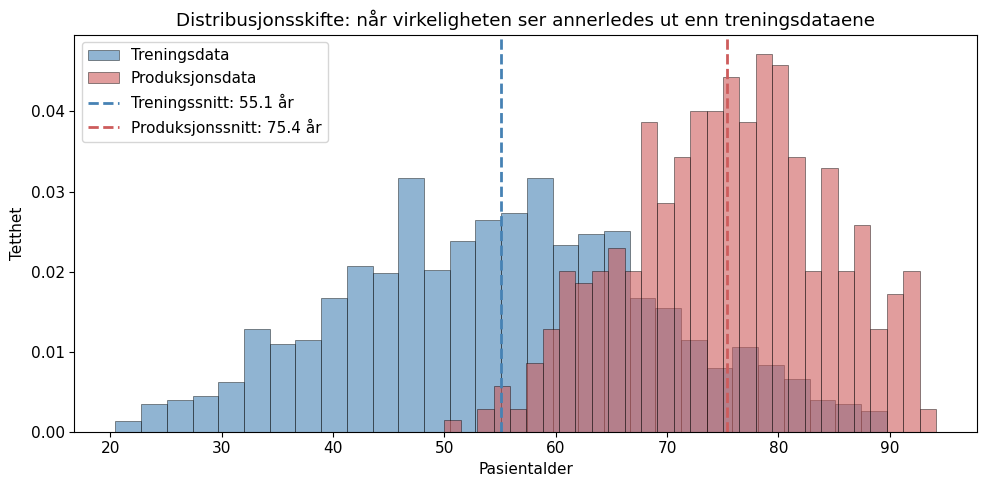

Hvis inngangsdata endrer seg, kan modellens ytelse falle uten at det oppdages med én gang.
Det er derfor viktig å overvåke om produksjonsdata fortsatt ligner på dataene modellen ble utviklet på.


In [8]:
# Demonstrasjon av distribusjonsskifte

# Vi lager først en syntetisk aldersfordeling som representerer treningsdataene.
# Her tenker vi oss at modellen ble utviklet på en relativt bred sykehuspopulasjon.
training_age = np.random.normal(55, 15, 1000)
training_age = training_age[(training_age > 20) & (training_age < 90)]

# Deretter lager vi en ny fordeling som representerer data i faktisk bruk.
# Her tenker vi oss en geriatrisk avdeling med eldre pasienter.
production_age = np.random.normal(75, 10, 500)
production_age = production_age[(production_age > 50) & (production_age < 95)]

# Figuren sammenligner de to fordelingene direkte.
# Når kurvene ligger forskjellig, illustrerer det at modellen møter en annen virkelighet enn under utvikling.
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(training_age, bins=30, alpha=0.6, label='Treningsdata', color='steelblue', density=True, edgecolor='black', linewidth=0.5)
ax.hist(production_age, bins=30, alpha=0.6, label='Produksjonsdata', color='indianred', density=True, edgecolor='black', linewidth=0.5)

# Vi markerer også gjennomsnittsalderen i hvert datasett for å gjøre forskjellen ekstra tydelig.
ax.axvline(training_age.mean(), color='steelblue', linestyle='--', linewidth=2, label=f'Treningssnitt: {training_age.mean():.1f} år')
ax.axvline(production_age.mean(), color='indianred', linestyle='--', linewidth=2, label=f'Produksjonssnitt: {production_age.mean():.1f} år')

ax.set_xlabel('Pasientalder')
ax.set_ylabel('Tetthet')
ax.set_title('Distribusjonsskifte: når virkeligheten ser annerledes ut enn treningsdataene')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print('Hvis inngangsdata endrer seg, kan modellens ytelse falle uten at det oppdages med én gang.')
print('Det er derfor viktig å overvåke om produksjonsdata fortsatt ligner på dataene modellen ble utviklet på.')

## Beskrivelse og tolkning av figuren om distribusjonsskifte

Figuren viser to aldersfordelinger som overlapper bare delvis. Den blå fordelingen representerer **treningsdata**, altså pasientene modellen opprinnelig ble utviklet på. Den røde fordelingen representerer **produksjonsdata**, altså pasientene modellen senere møter i klinisk bruk. De stiplede linjene markerer gjennomsnittsalderen i de to datasettene.

### Hva figuren konkret viser

- **Treningsdataene** har tyngdepunkt rundt midten av 50-årene.
- **Produksjonsdataene** har tyngdepunkt rundt midten av 70-årene.
- Det betyr at modellen i praksis brukes på en pasientgruppe som er betydelig eldre enn gruppen den i hovedsak lærte av.
- Fordelingene overlapper noe, men de er tydelig forskjøvet i forhold til hverandre.

### Hvorfor dette er viktig

Distribusjonsskifte betyr at inngangsdata i bruk ikke lenger ligner godt nok på inngangsdata under utvikling. Da kan modellen møte mønstre den ikke er tilstrekkelig kalibrert for. I helse kan dette være særlig alvorlig fordi:

- eldre pasienter kan ha andre sykdomsmønstre og komorbiditet enn yngre pasienter
- måleverdier og symptombilder kan arte seg annerledes i andre pasientgrupper
- sammenhengen mellom inngangsdata og riktig klinisk tolkning kan endre seg

En modell som virket god under utvikling, kan derfor få **lavere treffsikkerhet, dårligere kalibrering eller flere skjeve feil** når den tas i bruk i et nytt miljø.

### Klinisk tolkning

Tenk deg at modellen ble utviklet ved et generelt sykehus med bred aldersspredning, men senere brukes i en geriatrisk avdeling. Selv om variabelen her bare er alder, illustrerer figuren et mer generelt problem: AI-systemet møter en virkelighet som ser annerledes ut enn den statistiske verdenen det lærte fra. Det betyr ikke automatisk at modellen er ubrukelig, men det betyr at man **ikke kan ta tidligere ytelse for gitt**.

### Hva man bør gjøre når man ser et slikt mønster

- undersøke om modellens ytelse faktisk faller i den nye populasjonen
- analysere om enkelte undergrupper rammes mer enn andre
- sette opp monitorering som kan oppdage videre drift over tid
- vurdere ny validering eller retrening før systemet brukes bredt

Hovedpoenget er at distribusjonsskifte ofte er **stille**: modellen kan fortsatt gi prediksjoner, men kvaliteten kan ha blitt dårligere uten at det er åpenbart ved første øyekast. Derfor er denne typen figur viktig som en tidlig advarsel, ikke bare som en illustrasjon.

## 3. Usikkerhet og når AI bør si «jeg vet ikke»

En tillitsverdig modell bør ikke bare gi en anbefaling. Den bør også kunne uttrykke hvor sikker eller usikker den er.

To nyttige begreper er:

- **Epistemisk usikkerhet**: modellen mangler kunnskap, for eksempel fordi tilstanden er sjelden eller dårlig representert i treningsdata
- **Aleatorisk usikkerhet**: det er støy eller uklarhet i selve dataene, for eksempel dårlig bildekvalitet

I klinisk praksis er det ofte tryggere at AI-systemet signaliserer usikkerhet og utløser menneskelig vurdering, enn at det opptrer selvsikkert når grunnlaget er svakt.

### Typer usikkerhet

| Type | Beskrivelse | Medisinsk eksempel | Kan reduseres med |
|---|---|---|---|
| **Epistemisk usikkerhet** | Modellen er usikker fordi den mangler kunnskap | Sjeldne sykdommer eller få lignende treningscaser | Mer data, bedre modeller, mer representativ trening |
| **Aleatorisk usikkerhet** | Dataene er i seg selv utydelige eller støyende | Dårlig bildekvalitet, målefeil eller variasjon mellom skannere | Ofte vanskelig å redusere fullt ut; krever bedre datakvalitet eller menneskelig kontroll |

### Hvorfor betyr usikkerhet så mye?

```text
Høy konfidens + riktig svar   -> ofte nyttig og tillitvekkende
Høy konfidens + feil svar     -> potensielt farlig fordi systemet virker sikkert
Lav konfidens + usikkert svar -> tryggere dersom dette utløser menneskelig vurdering
```

Det sentrale poenget er derfor ikke at AI alltid skal være sikker, men at systemet skal være **ærlig om egen usikkerhet**. I helse er det ofte bedre at modellen sier «jeg vet ikke» enn at den er selvsikkert feil.

> Klinisk parallell: Laboratoriesvar oppgis ofte med referanseområde eller konfidensintervall. På samme måte bør AI-systemer i mange situasjoner kommunisere usikkerhet, ikke bare ett enkelt tall eller én etikett.

In [9]:
@dataclass
class KliniskPrediksjon:
    # Denne dataklassen samler de viktigste opplysningene om én AI-prediksjon.
    # Poenget er å vise at en klinisk relevant prediksjon bør inneholde mer enn bare ett tall.
    beskrivelse: str
    prediksjon: float
    usikkerhet: float
    usikkerhetstype: str


def vurder_handling(prediksjon, usikkerhet, terskel=0.20):
    # Reglene under er bevisst enkle.
    # De illustrerer hvordan usikkerhet kan brukes til å avgjøre om AI kan støtte handling,
    # eller om saken bør løftes til manuell vurdering.
    if usikkerhet > terskel:
        return 'Manuell vurdering nødvendig'
    if prediksjon > 0.80:
        return 'Høy konfidens positiv'
    if prediksjon < 0.20:
        return 'Høy konfidens negativ'
    return 'Manuell vurdering anbefales'


cases = [
    KliniskPrediksjon('Typisk pneumoni, godt representert i data', 0.85, 0.05, 'aleatorisk'),
    KliniskPrediksjon('Atypisk presentasjon, få lignende tilfeller', 0.65, 0.25, 'epistemisk'),
    KliniskPrediksjon('Sjelden autoimmun tilstand', 0.55, 0.40, 'epistemisk')
]

# Vi går gjennom noen enkle scenarioer for å se hvordan samme modell kan gi ulike anbefalinger
# avhengig av både prediksjon og graden av usikkerhet.
for i, case in enumerate(cases, start=1):
    handling = vurder_handling(case.prediksjon, case.usikkerhet)
    print(f"Tilfelle {i}: {case.beskrivelse}")
    print(f"  Prediksjon: {case.prediksjon:.0%}")
    print(f"  Usikkerhet: ±{case.usikkerhet:.0%} ({case.usikkerhetstype})")
    print(f"  Anbefalt handling: {handling}\n")

Tilfelle 1: Typisk pneumoni, godt representert i data
  Prediksjon: 85%
  Usikkerhet: ±5% (aleatorisk)
  Anbefalt handling: Høy konfidens positiv

Tilfelle 2: Atypisk presentasjon, få lignende tilfeller
  Prediksjon: 65%
  Usikkerhet: ±25% (epistemisk)
  Anbefalt handling: Manuell vurdering nødvendig

Tilfelle 3: Sjelden autoimmun tilstand
  Prediksjon: 55%
  Usikkerhet: ±40% (epistemisk)
  Anbefalt handling: Manuell vurdering nødvendig



## 4. Menneskelig kontroll, validering og monitorering

### Human-in-the-loop (mennesket i løkken)
I medisinsk AI bør mennesker normalt være inne i eller over beslutningsløkken. Det betyr at:

- AI gir støtte, ikke endelig ansvar
- klinikeren kan overstyre anbefalingen
- systemet bør være laget for gjennomgang, ikke blind tillit

### Tre nivåer av menneskelig involvering

| Nivå | Beskrivelse | Kontroll | Effektivitet | Typisk bruk i helse |
|---|---|---|---|---|
| **Human-in-the-loop** | Mennesket godkjenner hver beslutning | Høy | Lavere | Diagnostiske vurderinger med høy risiko |
| **Human-on-the-loop** | Mennesket overvåker og kan gripe inn | Middels til høy | Middels | Triage, varsling og prioritering |
| **Human-out-of-the-loop** | Systemet handler automatisk uten løpende menneskelig kontroll | Lav | Høy | Kan være aktuelt for svært lavrisiko-oppgaver, men bør ikke brukes ukritisk i diagnose og behandling |

I praksis vil mange medisinske AI-systemer ligge mellom de to første nivåene. Poenget er ikke å automatisere mest mulig, men å velge et nivå av kontroll som passer risikoen i oppgaven.

### Validering før innføring
Før et system tas i bruk, bør man minst spørre:

- Hvordan fungerte modellen på data den ikke ble trent på?
- Er den testet på andre pasientgrupper eller andre institusjoner?
- Finnes det subgrupper med tydelig svakere ytelse?

### Valideringsstrategier

| Strategi | Hva den undersøker | Hvorfor den er viktig |
|---|---|---|
| **Retrospektiv validering** | Test på historiske data | Første indikasjon på om modellen fungerer |
| **Prospektiv validering** | Test på nye pasienter framover i tid | Gir bedre bilde av reell klinisk bruk |
| **Ekstern validering** | Test på data fra andre sykehus eller settinger | Undersøker generaliserbarhet |
| **Subgruppeanalyse** | Ytelse i ulike pasientgrupper | Avdekker mulig skjevhet og svakheter |
| **Stresstesting og sjeldne tilfeller** | Sårbarhet ved uvanlige eller vanskelige tilfeller | Tester robusthet |
| **Stille driftstest** | Modellen kjører i bakgrunnen uten å påvirke behandling | Nyttig siste steg før reell innføring |

### Monitorering etter innføring
Selv et godt validert system kan forringes over tid. Derfor må man følge med på:

- endringer i inngangsdata
- endringer i ytelse
- overstyringsstatistikk fra klinikere
- antall usikre eller feilaktige anbefalinger

### Hva bør monitoreres etter innføring?

| Område | Hva man følger med på | Varseltegn |
|---|---|---|
| **Ytelse** | Treffsikkerhet, sensitivitet, spesifisitet over tid | Gradvis fall i kvalitet |
| **Distribusjonsskifte** | Endringer i alder, målinger, diagnosemønster eller utstyr | Produksjonsdata ligner mindre på treningsdata |
| **Feilmønstre** | Hvilke typer tilfeller modellen tar feil på | Flere feil i bestemte subgrupper |
| **Brukeratferd** | Hvor ofte klinikere overstyrer AI | Høy overstyringsrate kan bety lav tillit eller reelle feil |
| **Usikkerhet** | Hvor mange prediksjoner som flagges som usikre | Kan tyde på endret datagrunnlag eller svak robusthet |

> En modell er ikke ferdig bare fordi den er tatt i bruk. Den må følges opp som annet medisinsk utstyr og klinisk beslutningsstøtte.

In [10]:
def hitl_workflow(prediksjon, konfidens, kritisk=False):
    # Denne funksjonen illustrerer et enkelt prinsipp for menneskelig kontroll:
    # jo høyere risiko og jo høyere konfidens i et kritisk funn, desto tydeligere må oppfølgingen være.
    if kritisk and konfidens >= 0.95:
        return 'Haster: senior kliniker må varsles og bekrefte'
    if konfidens >= 0.80:
        return 'Vis anbefaling til kliniker for bekreftelse eller overstyring'
    return 'Flagg for manuell vurdering; AI brukes kun som støtteinformasjon'

scenarier = [
    ('Høy risiko for DVT', 0.92, True),
    ('Mulig pneumoni', 0.65, False),
    ('Høy risiko for lungeemboli', 0.97, True)
]

# Vi skriver ut noen eksempler for å vise hvordan samme system kan havne i ulike arbeidsflyter.
for navn, konfidens, kritisk in scenarier:
    print(f"Funn: {navn}")
    print(f"Konfidens: {konfidens:.0%}")
    print(f"Anbefalt arbeidsflyt: {hitl_workflow(navn, konfidens, kritisk)}\n")

Funn: Høy risiko for DVT
Konfidens: 92%
Anbefalt arbeidsflyt: Vis anbefaling til kliniker for bekreftelse eller overstyring

Funn: Mulig pneumoni
Konfidens: 65%
Anbefalt arbeidsflyt: Flagg for manuell vurdering; AI brukes kun som støtteinformasjon

Funn: Høy risiko for lungeemboli
Konfidens: 97%
Anbefalt arbeidsflyt: Haster: senior kliniker må varsles og bekrefte



## 5. Oppsummering

Et AI-system i helse er først virkelig tillitsverdig når det ikke bare leverer gode resultater i utviklingsfasen, men også:

- tåler endringer i data og kontekst
- signaliserer usikkerhet når det er grunn til det
- brukes med tydelig menneskelig kontroll
- er validert før innføring
- overvåkes etter at det er tatt i bruk

Denne notebooken henger tett sammen med både uke 06 og resten av uke 08:

- fra **uke 06** henter vi behovet for validering, generalisering og klinisk arbeidsflyt
- fra **uke 08** henter vi etikk, personvern, bias og regulering

Til sammen gir dette et mer realistisk bilde av hva som må til for å bruke AI forsvarlig i helse.

## Ordliste over sentrale begreper

Denne ordlisten samler sentrale uttrykk som går igjen i notebooken. Hensikten er å gjøre det lettere å lese både fagteksten og kodeeksemplene med et konsekvent norsk begrepsapparat.

### Tillit og styring

| Begrep | Kort forklaring |
|---|---|
| **Trustworthy AI** | AI som er pålitelig, sikker, rettferdig, forståelig og ansvarlig nok til å kunne brukes med tillit |
| **EU AI Act** | EUs regelverk for AI, med risikoklassifisering og krav til høyrisikosystemer |
| **CE-merking** | Europeisk samsvarsmerking som kan være relevant når AI inngår i medisinsk utstyr |
| **Ansvarlighet** | Tydelig fordeling av ansvar for beslutninger, feil og oppfølging |
| **Menneskelig kontroll** | At mennesker kan overvåke, gripe inn og overstyre systemet |

### Tekniske begreper

| Begrep | Kort forklaring |
|---|---|
| **Distribusjonsskifte** | Når data i bruk avviker fra data modellen ble trent på |
| **Robusthet** | Hvor godt modellen tåler variasjon, feil og krevende situasjoner |
| **Epistemisk usikkerhet** | Usikkerhet fordi modellen mangler kunnskap |
| **Aleatorisk usikkerhet** | Usikkerhet fordi dataene er støyende eller tvetydige |
| **Sjeldent grensetilfelle** | Uvanlig, men gyldig tilfelle som modellen kan streve med |

### Menneske-AI-samspill

| Begrep | Kort forklaring |
|---|---|
| **HITL** | Human-in-the-loop: mennesket godkjenner beslutninger |
| **HOTL** | Human-on-the-loop: mennesket overvåker og kan gripe inn |
| **HOOTL** | Human-out-of-the-loop: systemet handler uten løpende menneskelig kontroll |
| **Overstyringsrate** | Hvor ofte mennesket overstyrer AI-anbefalingen |
| **Automatiseringsbias** | Tendens til å stole for mye på automatiserte anbefalinger |

### Validering og drift

| Begrep | Kort forklaring |
|---|---|
| **Retrospektiv validering** | Testing på historiske data |
| **Prospektiv validering** | Testing på nye pasienter framover i tid |
| **Ekstern validering** | Testing på data fra andre institusjoner |
| **Stille driftstest** | Modellen kjører i bakgrunnen uten å påvirke kliniske beslutninger |
| **Kontinuerlig monitorering** | Løpende overvåking av modellens ytelse etter innføring |
| **Retrening** | Oppdatering av modellen med nye data når ytelsen svekkes |
